In [1]:
print("Kernel working properly")

Kernel working properly


# Data preparation and exploration notebook

This notebook will focus into running the data download files, as well as preparing the data for the training later on. 

## Cloning the repository - Google Colab

This step is needed for importing the src scripts. This is needed when execution through google colab

In [ ]:
!pip install -U ipython

In [ ]:
%load_ext autoreload
%autoreload 2

#Clone the repository
import os
if not os.path.exists("predictive_modeling_and_mobility_forecasting"):
    !git clone https://github.com/ras112git/predictive_modeling_and_mobility_forecasting.git
else:
    print("Repo already cloned.")


%cd predictive_modeling_and_mobility_forecasting

# Install dependencies
!pip install -r requirements.txt

import sys
sys.path.append(os.getcwd())

## Setting up environment localy (venv)

Local set up
```bash
python -m venv .venv
.venv\Scripts\activate          # Windows
pip install -r requirements.txt
pip install jupyter ipykernel
```


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

# Make src/ importable: add the project root (parent of notebooks/) to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Run from the project root so relative paths like "data/raw/..." resolve
os.chdir(project_root)
print(f"Working dir: {os.getcwd()}")

Working dir: c:\Users\ladak\Documents\GitHub\predictive_modeling_and_mobility_forecasting


## Download the raw data

In [2]:
from src.download_data import download_raw_data

train_path, test_path = download_raw_data()

Raw data already exists at data/raw\dataset_train.csv, skipping download.
Raw data already exists at data/raw\dataset_test.csv, skipping download.


## Data Import (when already downloaded)

In [3]:
import pandas as pd

# Start by importing the data
train_path = Path('data/raw/dataset_train.csv')
df_train = pd.read_csv(train_path)
test_path = Path('data/raw/dataset_test.csv')
df_test = pd.read_csv(test_path)

## Data Exploration

In [4]:
import pandas as pd

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

df_train.head()

Train shape: (2150250, 6)
Test shape:  (537445, 5)


,datetime,station_number,name,lat,lng,bikes
0,2024-09-03T17:30:00Z,32000,Julius-Raab-Platz,48.211544,16.382374,25
1,2024-09-03T17:30:00Z,32001,Hoher Markt,48.210666,16.372983,14
2,2024-09-03T17:30:00Z,32002,Oper,48.202683,16.369702,9
3,2024-09-03T17:30:00Z,32003,Volksgarten,48.206516,16.360400,3
4,2024-09-03T17:30:00Z,32004,Taborstraße U2,48.219522,16.382218,5


In [5]:
print(df_train['datetime'].str.len().mean())
print(df_train['datetime'].str.len().max())
print(df_train['datetime'].str.len().min())

20.0
20
20


In [6]:
# Raw line count from the file itself
with open(test_path, 'rb') as f:
    raw_lines = sum(1 for _ in f)

print(f"Raw lines in file: {raw_lines}")
print(f"Pandas shape: {df_test.shape}")
print(f"Fully empty rows: {df_test.isna().all(axis=1).sum()}")

Raw lines in file: 537446
Pandas shape: (537445, 5)
Fully empty rows: 0


## Data exploration and plotting

In [7]:
# First we start with data cleaning

from src.data_cleaning import clean_data

df_train = clean_data(dataset= df_train, 
                      is_train = True, 
                      categorize_station = True) # If I put false here, it splits the station data in bolean

df_train

,id,datetime,station_number,name,lat,lng,bikes,hour,minute,dayofweek,...,hour_sin,hour_cos,is_holiday,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m
0,2024-09-03 17:30:00_32000,2024-09-03 17:30:00,32000,Julius-Raab-Platz,48.211544,16.382374,25,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
1,2024-09-03 17:30:00_32001,2024-09-03 17:30:00,32001,Hoher Markt,48.210666,16.372983,14,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
2,2024-09-03 17:30:00_32002,2024-09-03 17:30:00,32002,Oper,48.202683,16.369702,9,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
3,2024-09-03 17:30:00_32003,2024-09-03 17:30:00,32003,Volksgarten,48.206516,16.360400,3,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
4,2024-09-03 17:30:00_32004,2024-09-03 17:30:00,32004,Taborstraße U2,48.219522,16.382218,5,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150245,2025-03-13 08:00:00_32275,2025-03-13 08:00:00,32275,eLastenräder - Am langen Felde,48.250224,16.450650,0,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150246,2025-03-13 08:00:00_32277,2025-03-13 08:00:00,32277,eLastenräder - Bruno-Marek-Allee 6,48.227914,16.391516,6,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150247,2025-03-13 08:00:00_32278,2025-03-13 08:00:00,32278,eLastenräder - Am Tabor 23,48.224598,16.392090,3,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150248,2025-03-13 08:00:00_32280,2025-03-13 08:00:00,32280,ALF Mobility-Point,48.251355,16.452810,5,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88


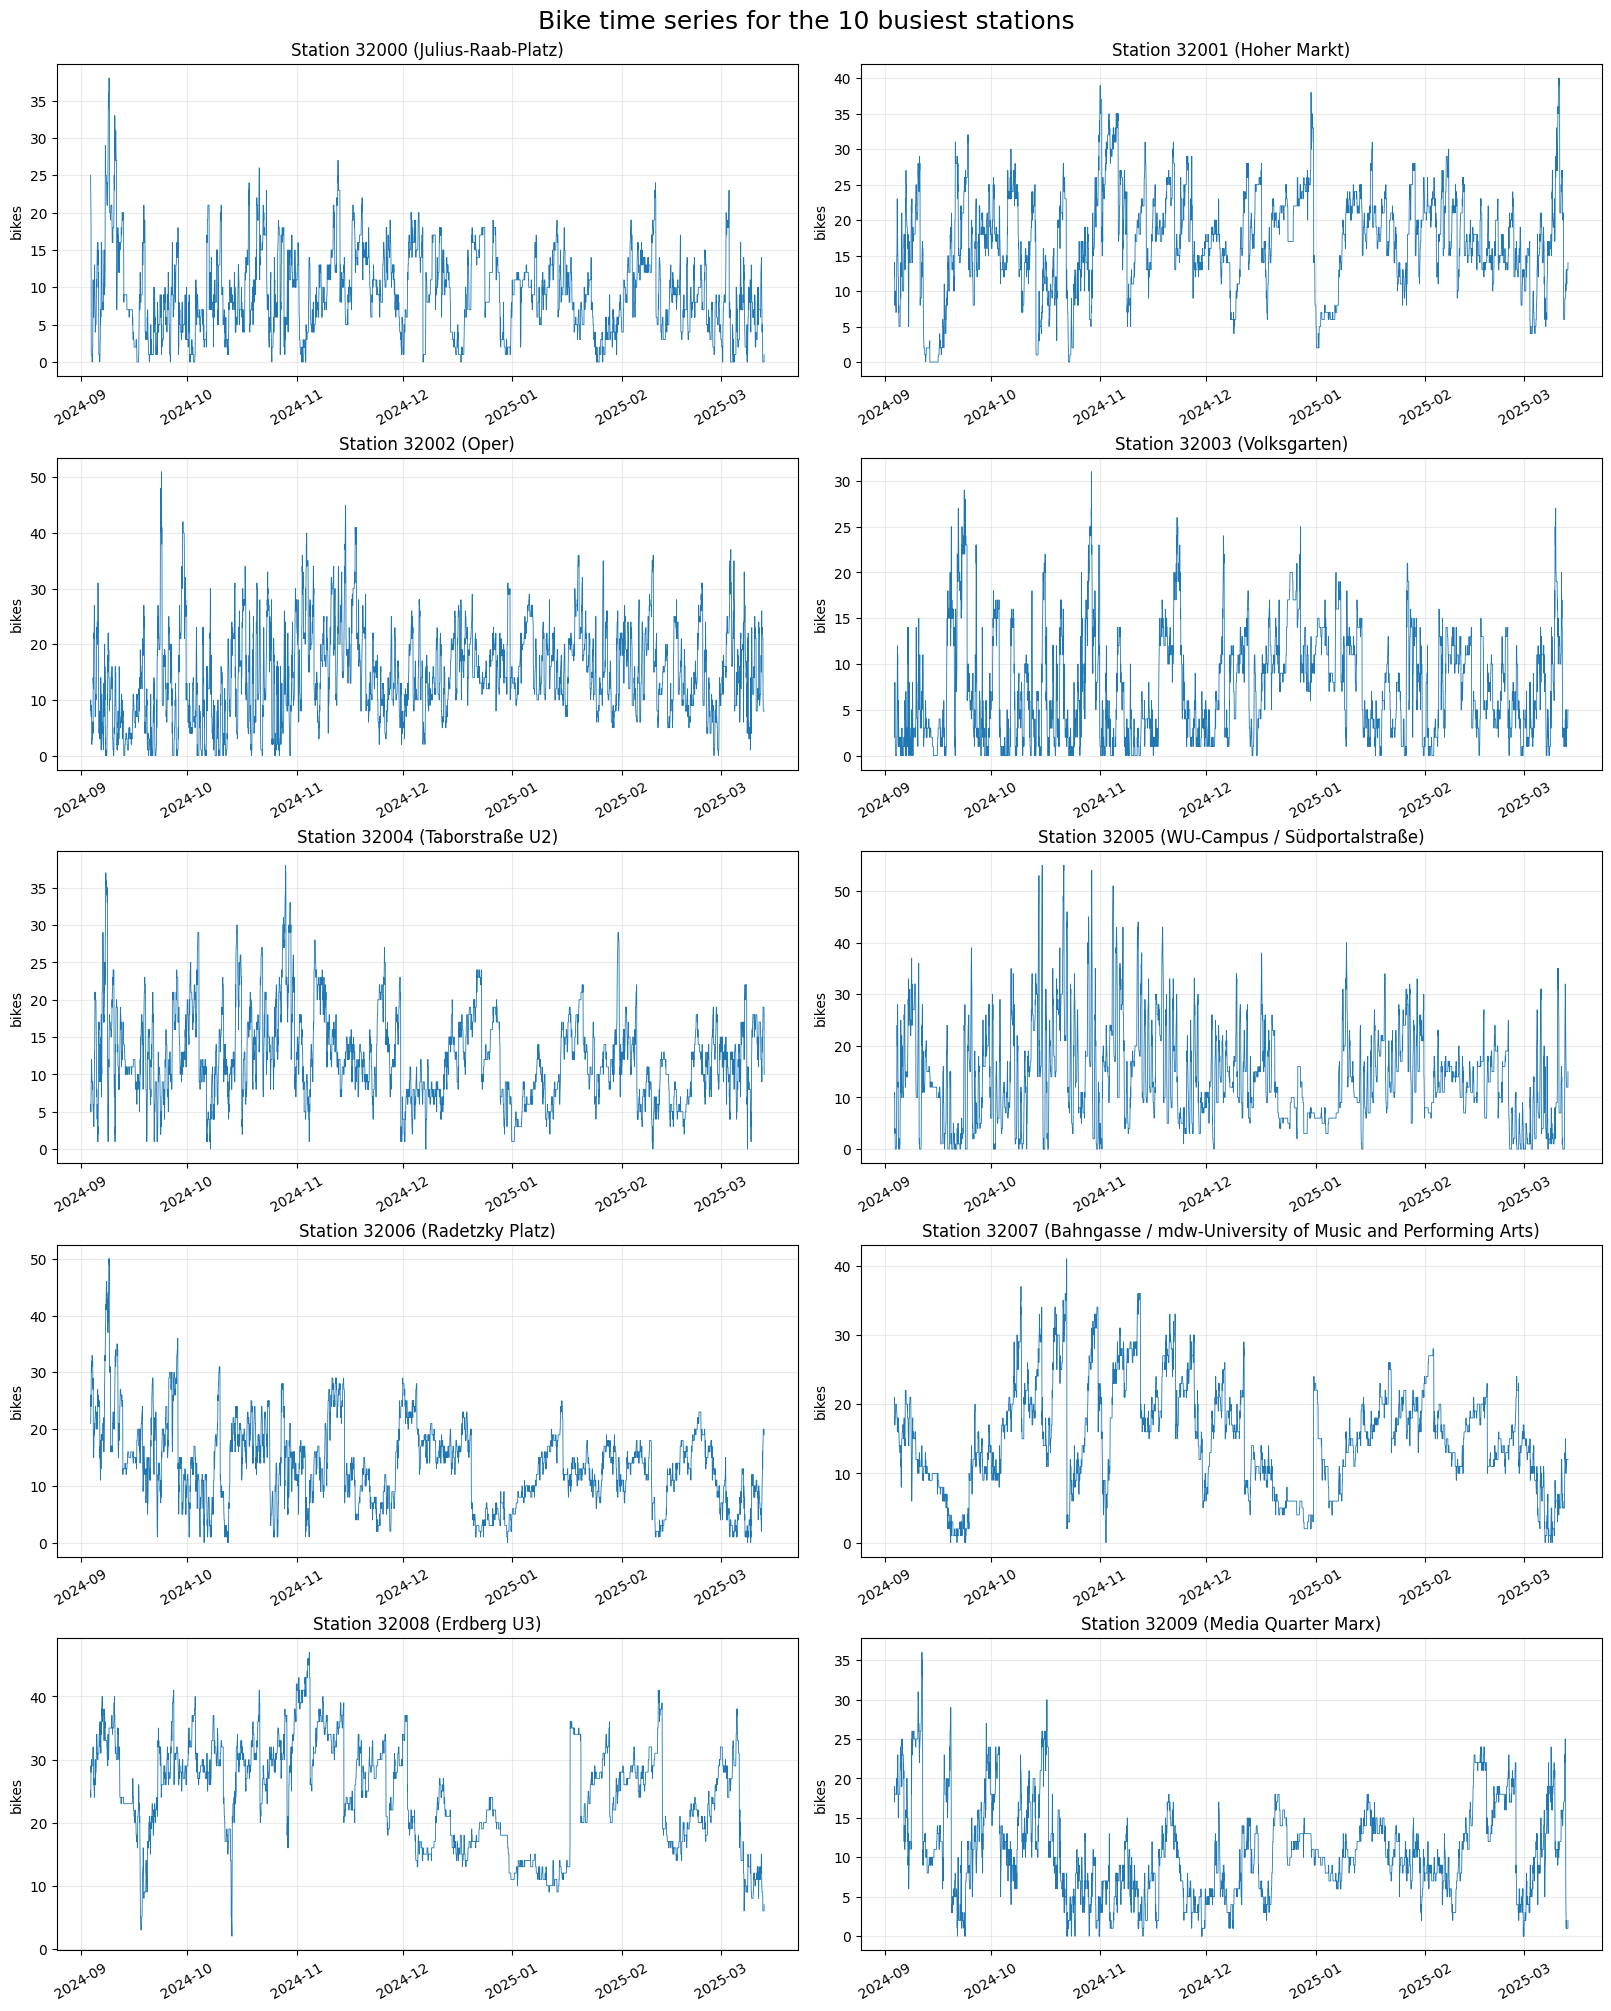

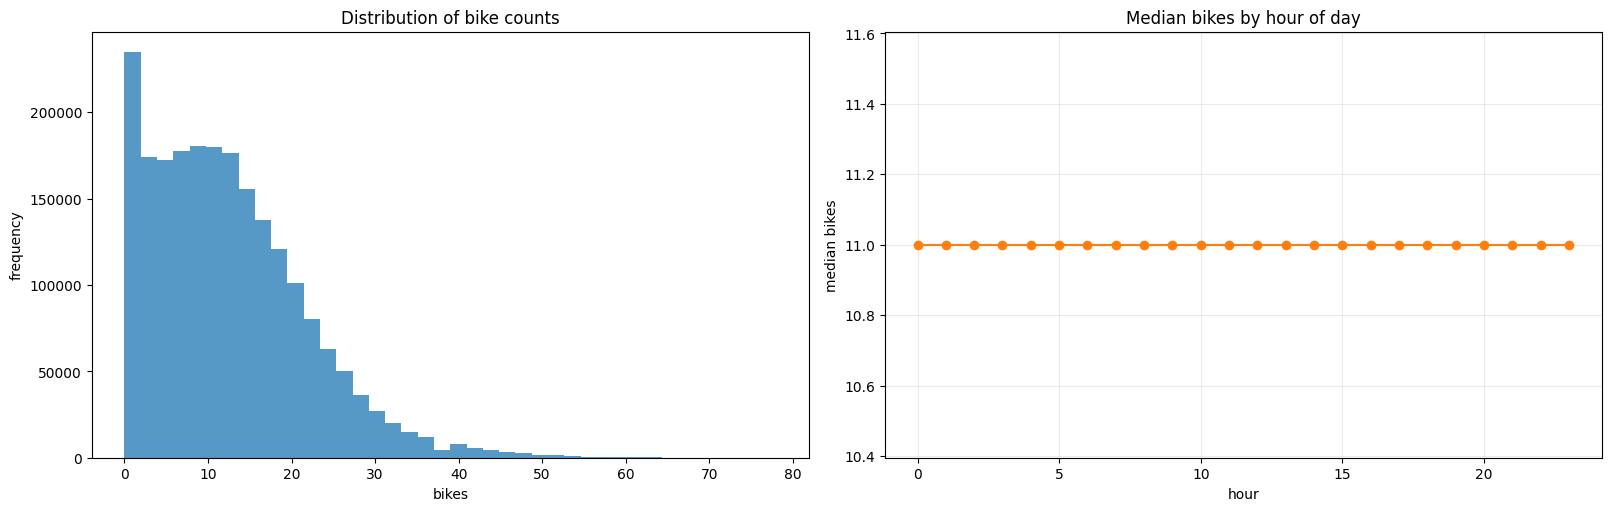

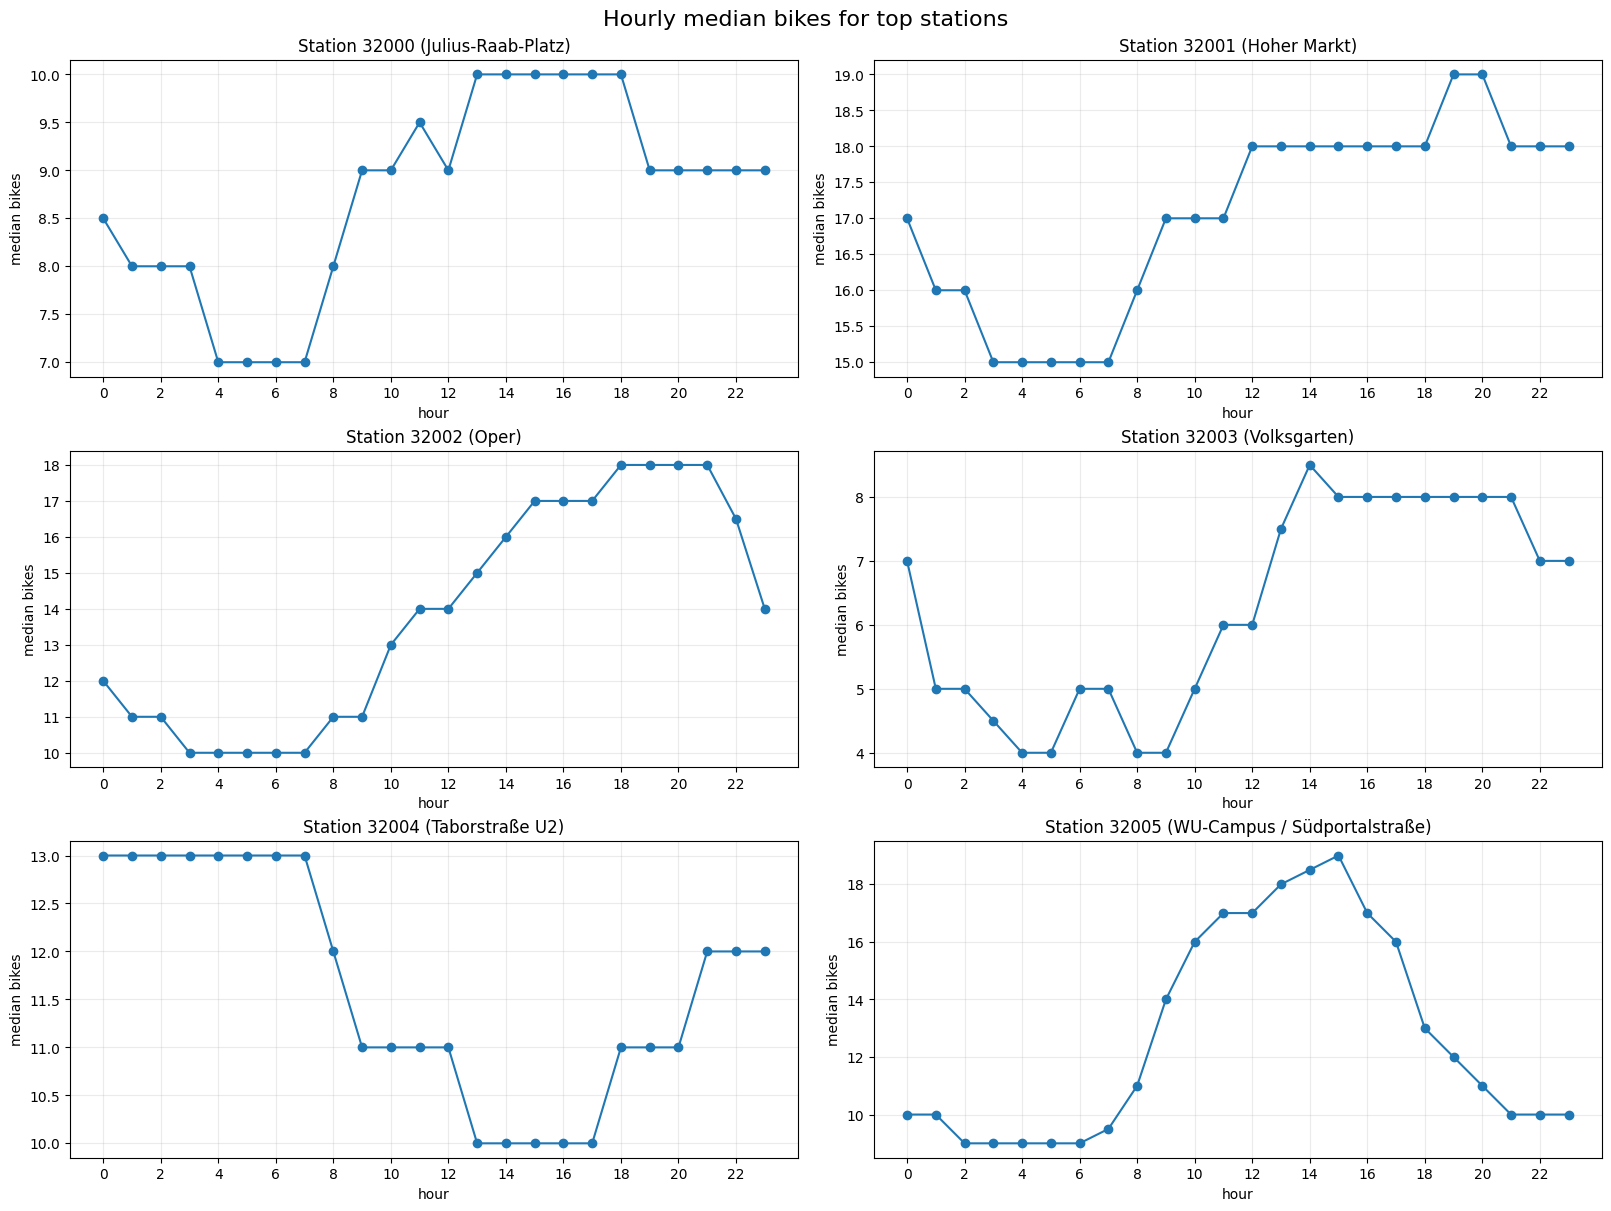

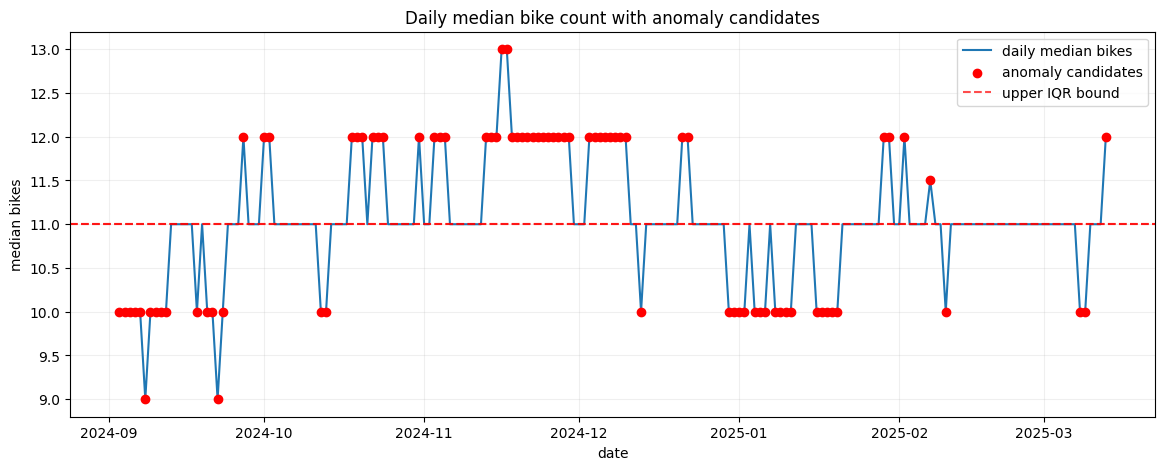

Candidate anomaly dates (daily median):
datetime
2024-11-17    13.0
2024-11-16    13.0
2024-10-01    12.0
2024-11-18    12.0
2024-11-15    12.0
2024-11-14    12.0
2024-11-03    12.0
2024-11-04    12.0
2024-11-13    12.0
2024-11-05    12.0


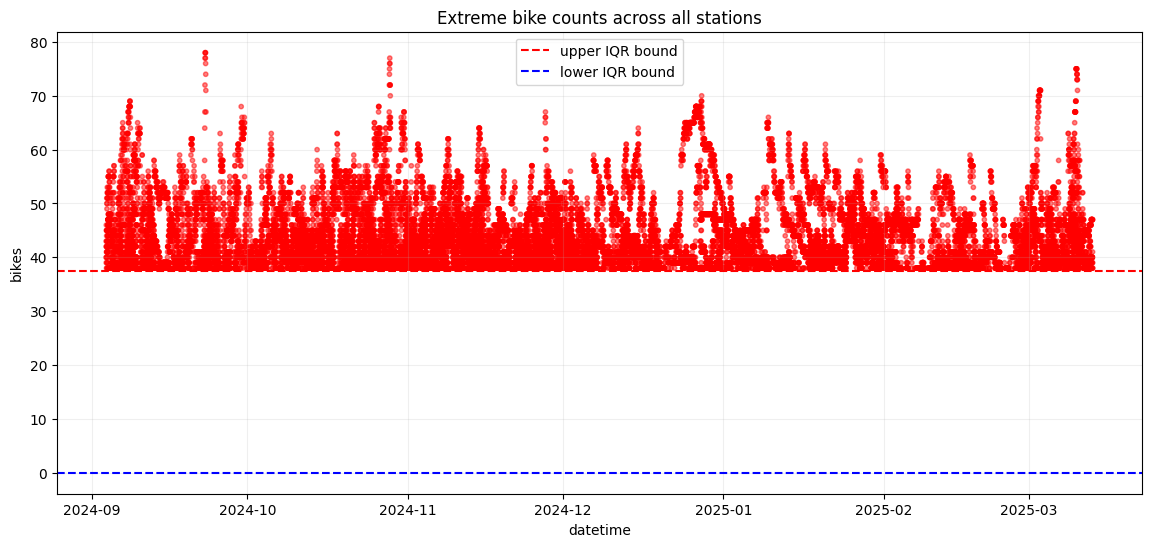


Total extreme bike count rows: 34319
           datetime station_number               name  hour  bikes
2024-09-22 22:00:00          32073    Praterstern S U    22     78
2024-09-22 20:30:00          32073    Praterstern S U    20     78
2024-09-22 21:00:00          32073    Praterstern S U    21     78
2024-09-22 21:30:00          32073    Praterstern S U    21     77
2024-09-22 20:00:00          32073    Praterstern S U    20     77
2024-10-28 12:30:00          32219 Schloss Schönbrunn    12     77
2024-09-22 22:30:00          32073    Praterstern S U    22     76
2024-10-28 13:00:00          32219 Schloss Schönbrunn    13     76
2024-10-28 12:00:00          32219 Schloss Schönbrunn    12     76
2024-10-28 11:30:00          32219 Schloss Schönbrunn    11     75


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the datetime column is parsed and ready for plotting.
if df_train['datetime'].dtype == 'object':
    df_train['datetime'] = pd.to_datetime(df_train['datetime'], utc=True).dt.tz_localize(None)

# === 1) Time series plots for the 10 busiest stations ===
most_active = df_train['station_number'].value_counts().nlargest(10).index.tolist()
fig, axes = plt.subplots(5, 2, figsize=(16, 20), constrained_layout=True)
for ax, station in zip(axes.flatten(), most_active):
    station_data = df_train[df_train['station_number'] == station].sort_values('datetime')
    ax.plot(station_data['datetime'], station_data['bikes'], lw=0.6)
    ax.set_title(f"Station {station} ({station_data['name'].iloc[0]})")
    ax.set_ylabel('bikes')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
fig.suptitle('Bike time series for the 10 busiest stations', fontsize=18)
plt.show()

# === 2) Distribution and hour-level behavior ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
axes[0].hist(df_train['bikes'], bins=40, color='tab:blue', alpha=0.75)
axes[0].set_title('Distribution of bike counts')
axes[0].set_xlabel('bikes')
axes[0].set_ylabel('frequency')

hourly = df_train.groupby('hour')['bikes'].median()
axes[1].plot(hourly.index, hourly.values, marker='o', color='tab:orange')
axes[1].set_title('Median bikes by hour of day')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('median bikes')
axes[1].grid(alpha=0.25)
plt.show()

# === 2b) Median bikes by hour for top stations ===
top_stations = df_train['station_number'].value_counts().nlargest(6).index.tolist()
fig, axes = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)
for ax, station in zip(axes.flatten(), top_stations):
    station_data = df_train[df_train['station_number'] == station]
    med_by_hour = station_data.groupby('hour')['bikes'].median()
    ax.plot(med_by_hour.index, med_by_hour.values, marker='o')
    ax.set_title(f"Station {station} ({station_data['name'].iloc[0]})")
    ax.set_xlabel('hour')
    ax.set_ylabel('median bikes')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.25)
for ax in axes.flatten()[len(top_stations):]:
    ax.set_visible(False)
plt.suptitle('Hourly median bikes for top stations', fontsize=16)
plt.show()

# === 3) Aggregate trend and anomaly candidates ===
daily_median = df_train.set_index('datetime').resample('D')['bikes'].median()
q1, q3 = daily_median.quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = max(q1 - 1.5 * iqr, 0)
anomaly_dates = daily_median[(daily_median > upper_bound) | (daily_median < lower_bound)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_median.index, daily_median.values, label='daily median bikes', color='tab:blue')
ax.scatter(anomaly_dates.index, anomaly_dates.values, color='red', label='anomaly candidates', zorder=3)
ax.axhline(upper_bound, color='red', linestyle='--', alpha=0.7, label='upper IQR bound')
ax.axhline(lower_bound, color='red', linestyle='--', alpha=0.7)
ax.set_title('Daily median bike count with anomaly candidates')
ax.set_ylabel('median bikes')
ax.set_xlabel('date')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

print('Candidate anomaly dates (daily median):')
print(anomaly_dates.sort_values(ascending=False).head(10).to_string())

# === 4) Station-level extreme values ===
q1, q3 = df_train['bikes'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = max(q1 - 1.5 * iqr, 0)
extreme = df_train[(df_train['bikes'] > upper) | (df_train['bikes'] < lower)]

fig, ax = plt.subplots(figsize=(14, 6))
colors = np.where(extreme['bikes'] > upper, 'red', 'blue')
ax.scatter(extreme['datetime'], extreme['bikes'], c=colors, alpha=0.5, s=10)
ax.axhline(upper, color='red', linestyle='--', label='upper IQR bound')
ax.axhline(lower, color='blue', linestyle='--', label='lower IQR bound')
ax.set_title('Extreme bike counts across all stations')
ax.set_xlabel('datetime')
ax.set_ylabel('bikes')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

print(f"\nTotal extreme bike count rows: {len(extreme)}")
print(extreme[['datetime', 'station_number', 'name', 'hour', 'bikes']].sort_values('bikes', ascending=False).head(10).to_string(index=False))

## Feature selection methodologies

This section evaluates which input variables are most useful for predicting `bikes`.
We start with exploratory feature ranking using a tree-based regressor, then inspect the top features.

Using features: ['hour', 'minute', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_holiday', 'lat', 'lng', 'station_code', 'temperature_2m', 'apparent_temperature', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m']
Top 10 feature importances:
station_code            0.412716
lat                     0.250413
lng                     0.204889
month                   0.063875
apparent_temperature    0.018205
temperature_2m          0.016878
wind_speed_10m          0.007824
relative_humidity_2m    0.007786
dayofweek               0.005754
cloud_cover             0.003320


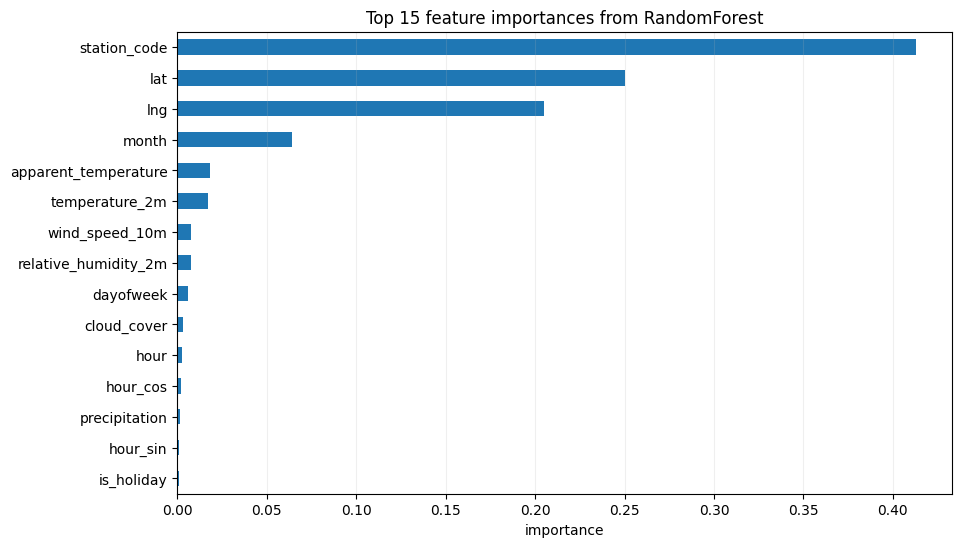

,feature,importance,rank
0,station_code,0.412716,1
1,lat,0.250413,2
2,lng,0.204889,3
3,month,0.063875,4
4,apparent_temperature,0.018205,5
5,temperature_2m,0.016878,6
6,wind_speed_10m,0.007824,7
7,relative_humidity_2m,0.007786,8
8,dayofweek,0.005754,9
9,cloud_cover,0.003320,10


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Prepare a feature matrix from available cleaned columns.
feature_columns = [
    'hour', 'minute', 'dayofweek', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'is_holiday',
    'lat', 'lng'
]

# Convert station_number to integer codes for model ranking.
if df_train['station_number'].dtype.name == 'category':
    df_train['station_code'] = df_train['station_number'].cat.codes
else:
    df_train['station_code'] = pd.Categorical(df_train['station_number']).codes
feature_columns.append('station_code')

# Include weather variables if available.
weather_columns = [
    'temperature_2m', 'apparent_temperature', 'precipitation',
    'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m'
]
feature_columns += [c for c in weather_columns if c in df_train.columns]

print('Using features:', feature_columns)

X = df_train[feature_columns]
y = df_train['bikes']

# Use a light sample if dataset is very large, to keep the first evaluation fast.
if len(df_train) > 300_000:
    X, _, y, _ = train_test_split(X, y, train_size=300_000, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
print('Top 10 feature importances:')
print(importances.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='barh', ax=ax, color='tab:blue')
ax.invert_yaxis()
ax.set_title('Top 15 feature importances from RandomForest')
ax.set_xlabel('importance')
ax.grid(alpha=0.2, axis='x')
plt.show()

# Summary table for top features
importance_df = importances.reset_index()
importance_df.columns = ['feature', 'importance']
importance_df['rank'] = importance_df['importance'].rank(method='first', ascending=False).astype(int)
importance_df.head(10)

### Station identity vs general predictors

We compare three models:
1. time + holiday + weather only,
2. time + holiday + weather + `station_code`,
3. time + holiday + weather + `lat`,`lng`.

This will show whether the model is learning general temporal patterns or simply station identity.

Baseline features:
['hour', 'minute', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_holiday', 'temperature_2m', 'apparent_temperature', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m']
Station code features:
['hour', 'minute', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_holiday', 'temperature_2m', 'apparent_temperature', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 'station_code']
Location features:
['hour', 'minute', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_holiday', 'temperature_2m', 'apparent_temperature', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 'lat', 'lng']
Baseline: R2=-0.0032, RMSE=9.456
Station code: R2=0.5361, RMSE=6.430
Location: R2=0.5404, RMSE=6.400

Comparison of models:
          model        r2      rmse
0      Baseline -0.003165  9.455741
1  Station code  0.536117  6.430038
2      Locatio

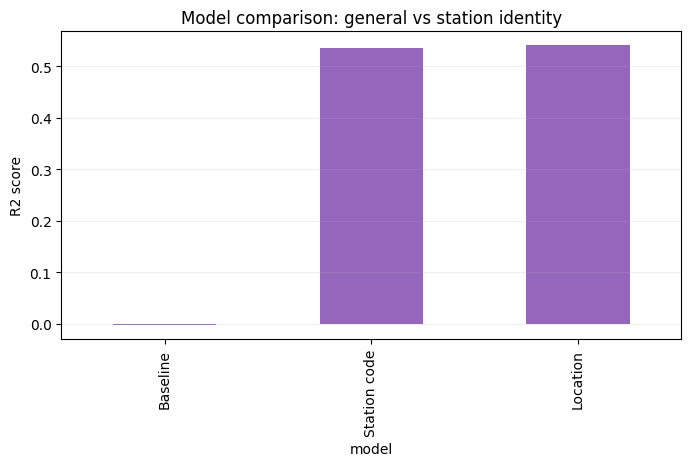


Feature importances for the station-code model:
station_code            0.903011
month                   0.046071
temperature_2m          0.016554
apparent_temperature    0.013753
relative_humidity_2m    0.004781
wind_speed_10m          0.004121
dayofweek               0.003474
cloud_cover             0.002513
hour                    0.001610
hour_cos                0.001198


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

baseline_features = [
    'hour', 'minute', 'dayofweek', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'is_holiday'
]

# Only keep weather features that exist in this cleaned dataset.
baseline_features += [c for c in weather_columns if c in df_train.columns]

station_code_features = baseline_features + ['station_code']
location_features = baseline_features + ['lat', 'lng']

print('Baseline features:')
print(baseline_features)
print('Station code features:')
print(station_code_features)
print('Location features:')
print(location_features)

sample_size = min(180_000, len(df_train))

results = []
for name, cols in [
    ('Baseline', baseline_features),
    ('Station code', station_code_features),
    ('Location', location_features)
]:
    X = df_train[cols]
    y = df_train['bikes']
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    results.append((name, score, rmse, cols, model))
    print(f'{name}: R2={score:.4f}, RMSE={rmse:.3f}')

results_df = pd.DataFrame([
    {'model': name, 'r2': score, 'rmse': rmse}
    for name, score, rmse, _, _ in results
])
print('\nComparison of models:')
print(results_df)

fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index('model')[['r2']].plot(kind='bar', ax=ax, legend=False, color=['tab:purple'])
ax.set_ylabel('R2 score')
ax.set_title('Model comparison: general vs station identity')
ax.grid(alpha=0.2, axis='y')
plt.show()

print('\nFeature importances for the station-code model:')
station_model = [m for name, _, _, _, m in results if name == 'Station code'][0]
station_importances = pd.Series(station_model.feature_importances_, index=station_code_features).sort_values(ascending=False)
print(station_importances.head(10).to_string())

### Filter-based feature inspection

Now we inspect correlation between candidate features and the target to compare model-based ranking with simple statistical relationships.

Correlation with bikes (descending):
lat                     0.041416
relative_humidity_2m    0.023887
month                   0.013034
hour_cos                0.011986
hour_sin                0.011777
cloud_cover             0.006306
is_holiday              0.001058
snowfall                0.000938
precipitation           0.000218
minute                 -0.000138
dayofweek              -0.001506
is_weekend             -0.003027
wind_speed_10m         -0.005462
hour                   -0.009552
apparent_temperature   -0.020880
temperature_2m         -0.021961
station_code           -0.138299
lng                    -0.167453


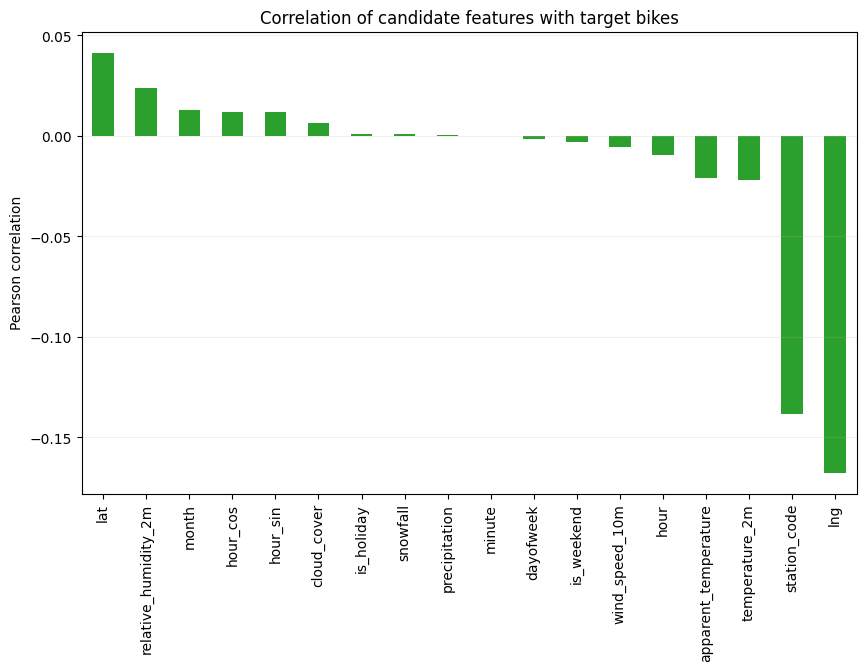

In [11]:
# Correlation of numeric features with the target
corr = df_train[feature_columns + ['bikes']].corr()['bikes'].drop('bikes').sort_values(ascending=False)
print('Correlation with bikes (descending):')
print(corr.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
corr.plot(kind='bar', color='tab:green', ax=ax)
ax.set_title('Correlation of candidate features with target bikes')
ax.set_ylabel('Pearson correlation')
ax.grid(alpha=0.2, axis='y')
plt.show()